# Step 1: Import Library

In [70]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from tqdm import tqdm
import random
import numpy as np
import matplotlib.pyplot as plt

In [71]:
torch.__version__

'2.8.0+cu126'

# Step 2 : Set up GPU

In [72]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [73]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
random.seed(42)

# Step 3 : Hyperparameter

In [74]:
BATCH_SIZE = 128
EPOCHS = 100 # BEFORE 25 , 60 for 62% accuracy , now tyring 100
LEARNING_RATE = 3e-4
PATCH_SIZE = 4 # 4X4
NUM_CLASSES = 10 # 10 Classes airplane , bus etc
IMAGE_SIZE = 32
CHANNELS = 3
EMBED_DIM = 256
NUM_HEADS = 8  # Number of multi head attentions
DEPTH = 6 # before 6 TRANSFORMERS, before 8 now 6
MLP_DIM = 768
DROPOUT_RATE = 0.1
WEIGHT_DECAY = 0.01 # ADDED FOR AUG

# step 4 : Image Transformation

In [75]:
# before augmentation
before_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = (0.5) , std = (0.5)), # helps to make model converge faster # 2. helps to make numerical computations stable

])

#after augmentation
after_transform = transforms.Compose([
    transforms.RandomCrop(32 , padding = 4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

## Step 5 : Getting Dataset

In [76]:
train_dataset = datasets.CIFAR10(root ="data/train" , download=True , transform = after_transform , train=True)

In [77]:
test_dataset = datasets.CIFAR10(root ="data/test" , download=True , transform = after_transform , train=False)

In [78]:
train_dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data/train
    Split: Train
    StandardTransform
Transform: Compose(
               RandomCrop(size=(32, 32), padding=4)
               RandomHorizontalFlip(p=0.5)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )

In [79]:
test_dataset

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: data/test
    Split: Test
    StandardTransform
Transform: Compose(
               RandomCrop(size=(32, 32), padding=4)
               RandomHorizontalFlip(p=0.5)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )

# Step 6 : Converting pytorchDatasets into DataLoaders

DataLoader converts it into iterable batches or (mini-batches)
1. More computationally efficient(i.e not able to store 50k data in on loop in ram to divide it into batches of 128 images)

2. It gives our neural network to update its gradient in each epoch


In [80]:
train_loader = DataLoader(dataset = train_dataset , batch_size=BATCH_SIZE , shuffle = True , pin_memory = True)
test_loader = DataLoader(dataset = test_dataset , batch_size=BATCH_SIZE , shuffle = False, pin_memory = True)

In [81]:
# Let's check out what we've created
print(f"DataLoader: {train_loader, test_loader}")
print(f"Length of train_loader: {len(train_loader)} batches of {BATCH_SIZE}...")
print(f"Length of test_loader: {len(test_loader)} batches of {BATCH_SIZE}...")

DataLoader: (<torch.utils.data.dataloader.DataLoader object at 0x7da049f26e70>, <torch.utils.data.dataloader.DataLoader object at 0x7da049f27290>)
Length of train_loader: 391 batches of 128...
Length of test_loader: 79 batches of 128...


# Step 7 : Building Vision Transfomer model From Scratch

In [82]:
# class Patch_Embedding(nn.Module):
#   def __init__(self ,image_size ,patch_size ,in_channels , embed_dim ):
#     super().__init__()
#     self.patch_size = patch_size
#     self.projection = nn.Conv2d(
#         in_channels = in_channels,
#         out_channels = embed_dim,
#         kernel_size = patch_size,
#         stride = patch_size,
#     )

#     num_patches = (image_size // patch_size) ** 2
#     self.pos_embedding = nn.Parameter(torch.randn(1, 1 + num_patches , embed_dim))
#     self.cls_token = nn.Parameter(torch.randn(1 , 1, embed_dim))


#   def forward(self , x : torch.Tensor):
#     B = x.size(0)
#     x = self.projection(x) # ( B , E , H/P , W/P)
#     x = x.flatten(2).transpose(1,2) #( B, N, E)

#     cls_tokens = self.cls_token.expand(B, -1, -1)
#     x = torch.cat((cls_tokens, x), dim=1)
#     x = x + self.pos_embedding

#     return x


    # ------------------------------New Code
class PatchEmbedding(nn.Module):
    def __init__(self, image_size , patch_size , in_channels , embed_dim):
        super().__init__()

        self.patch_size = patch_size
        self.projection = nn.Conv2d(
            in_channels= in_channels,
            out_channels= embed_dim,
            kernel_size= patch_size,
            stride= patch_size
        )

        num_patches = (image_size // patch_size) ** 2
        self.pos_encoding = nn.Parameter(torch.randn(1 , 1 + num_patches , embed_dim))
        self.cls_token = nn.Parameter(torch.randn(1 , 1 , embed_dim))

    def forward(self, x : torch.Tensor):
        # X is (Batch, Channels, Height, Width).
        B , _ , _ , _ = x.size() # we want only the Batch

        x = self.projection(x) # (Batch, Embed_dim, Patch_rows, Patch_cols)

        x = x.flatten(2).transpose(1 , 2) # (Batch, Num_patches, Embed_dim),

        # before cls token was random number b/w 0 to 1 and its dim was (1 , 1 , 768)
        cls_token = self.cls_token.expand(B , -1 , -1)
        # here -1 means don't change its dimension only channge Batch on the first position (B , 1 , 768)

        x = torch.concat((x , cls_token) , dim= 1)
        # cls_token (B , 1 , 768)
        # x         (B , 196 , 768)
        # final x = (B , 197 , 768) i.e only add 1 + 196 as they are dimension 1...

        x = x + self.pos_encoding
        # pos encoding = (1 , 197 , 768)
        # after broadcasting done by  pytorch the final shape of pos encoding is (B , 197 , 768)
        # final x      = (B , 197 , 768) as it does element wise addition but the dimesnion remains the same

        return x     # shape : (B , 197 , 768)

In [83]:
# class MLP(nn.Module):
#   def __init__(self , in_features , hidden_features , dropout_rate ):
#     super().__init__()

#     self.fc1 = nn.Linear(in_features= in_features , out_features = hidden_features)

#     self.fc2 = nn.Linear(in_features = hidden_features , out_features= in_features)

#     self.dropout = nn.Dropout(p = dropout_rate)

#   def forward(self , x):
#     x = self.fc1(x)
#     x = F.gelu(x)
#     x = self.dropout(x)
#     x = self.fc2(x)
#     x = self.dropout(x)

#     return x
    # --------------------------------
class MLP(nn.Module):
    def __init__(self , in_features , hidden_features, dropout_rate):
        super().__init__()

        self.fc1 = nn.Linear(in_features= in_features , out_features= hidden_features)

        self.fc2 = nn.Linear(in_features= hidden_features , out_features= in_features)

        self.dropout = nn.Dropout(p = dropout_rate)

    def forward(self , x):
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.dropout(x)

        # GELU is applied after fc1 for non-linearity. --->dding a non-linear activation lets the network capture more complex, real-world data.

        # fc2 is linear to preserve the residual structure. --->  The output is just a weighted sum (plus bias), so it remains a linear transformation.
        return x

In [84]:
# class TransformerEncoderLayer(nn.Module):
#   def __init__(self , embed_dim , num_heads , mlp_dim , dropout_rate):
#     super().__init__()

#     self.norm1 = nn.LayerNorm(embed_dim)

#     self.attention = nn.MultiheadAttention(embed_dim , num_heads=num_heads , dropout=dropout_rate , batch_first = True)

#     self.norm2 = nn.LayerNorm(embed_dim)

#     self.mlp = MLP(embed_dim , mlp_dim , dropout_rate)

#   def forward(self , x):
#     residual = x
#     x = self.norm1(x)
#     x , _ = self.attention(x , x , x) # or  x = self.attention(x , x , x)[0]
#     x = x + residual

#     residual = x
#     x = self.norm2(x)
#     x = self.mlp(x)

#     return x

    # ------------------------

class Transformer_Encoder_Layer(nn.Module):
    def __init__(self , embed_dim , num_heads , mlp_dim , dropout_rate):
        super().__init__()

        self.normalization_layer_1 = nn.LayerNorm(embed_dim)

        self.multi_head_attention = nn.MultiheadAttention(embed_dim=embed_dim , num_heads= num_heads , dropout= dropout_rate , batch_first= True)
        #batch first tells the layer our input data will be in the (Batch, Sequence, Embedding) format.

        self.mlp = MLP(embed_dim , mlp_dim , dropout_rate)

        self.normalization_layer_2 = nn.LayerNorm(embed_dim)

    def forward(self , x):
        residual_1 = x

        x = self.normalization_layer_1(x)

        x , _ = self.multi_head_attention(x , x , x)
        # The MultiheadAttention layer returns two things: the processed data and the attention weights. We only need the data, so we take the first item (x, _ or [0]).

        x = x + residual_1

        residual_2 = x

        x = self.normalization_layer_2(x)

        x = self.mlp(x)

        x = x + residual_2

        return x

In [85]:
# class VisionTransformer(nn.Module):
#   def __init__(self , image_size , patch_size , in_channels , num_classes , embed_dim , num_heads , depth , mlp_dim , dropout_rate):
#     super().__init__()

#     self.patch_embed = Patch_Embedding(image_size=image_size , patch_size=patch_size , in_channels=in_channels , embed_dim=embed_dim)

#     self.encoder = nn.Sequential(*[
#         TransformerEncoderLayer(embed_dim , num_heads , mlp_dim , dropout_rate)
#         for _ in range(depth)
#     ])


#     self.norm = nn.LayerNorm(embed_dim)

#     self.head = nn.Linear(embed_dim , num_classes)

#   def forward(self, x):
#     x = self.patch_embed(x)
#     x = self.encoder(x)
#     x = self.norm(x)
#     cls_token = x[:, 0]
#     x = self.head(cls_token)

#     return x

# -------------------

class Vision_Transformer_Class(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, num_classes, embed_dim, num_heads, depth, mlp_dim, dropout_rate):
        super().__init__()

        # Patch embedding: splits image into patches and projects to embedding dimension
        self.patch_embedding = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)

        # Stack multiple transformer encoder layers
        self.encoder_layer = nn.Sequential(*[
            Transformer_Encoder_Layer(embed_dim, num_heads, mlp_dim, dropout_rate)
            for _ in range(depth)
        ])

        # Final normalization before classification
        self.normalization_layer = nn.LayerNorm(embed_dim)

        # Classification head: maps CLS token embedding to class logits
        self.classification_head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):  # <-- Added input argument
        # x: (Batch, Channels, Height, Width)
        x = self.patch_embedding(x)  # (Batch, Num_patches+1, Embed_dim)

        x = self.encoder_layer(x)    # (Batch, Num_patches+1, Embed_dim)

        x = self.normalization_layer(x)  # (Batch, Num_patches+1, Embed_dim)

        cls_token = x[:, 0]  # Select CLS token for each batch: (Batch, Embed_dim)
        #means take all the batch , select first row only and select all its column or x[: , 0 , : ]

        x = self.classification_head(cls_token)  # Get class logits

        return x  # (Batch, Num_classes)

# Model Instantiation

In [86]:
model = Vision_Transformer_Class(
    IMAGE_SIZE,
    PATCH_SIZE,
    CHANNELS,
    NUM_CLASSES,
    EMBED_DIM,
    NUM_HEADS,  # 8
    DEPTH,      # 6
    MLP_DIM,
    DROPOUT_RATE
).to(device)

In [87]:
model

Vision_Transformer_Class(
  (patch_embedding): PatchEmbedding(
    (projection): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder_layer): Sequential(
    (0): Transformer_Encoder_Layer(
      (normalization_layer_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (multi_head_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (mlp): MLP(
        (fc1): Linear(in_features=256, out_features=768, bias=True)
        (fc2): Linear(in_features=768, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (normalization_layer_2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (1): Transformer_Encoder_Layer(
      (normalization_layer_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (multi_head_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=25

# Step 8 : loss function and optimizer

In [88]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Step 9 : Train Model

In [89]:
def train(model , loader , optimizer , criterion ):
  # set the mode of the model to the training mode
  model.train()

  total_loss , correct_predictions = 0 , 0

  for x , y in loader:
    x , y = x.to(device) , y.to(device)

    optimizer.zero_grad()
    # forward
    out = model(x)

    #loss
    loss = criterion(out , y)

    #optimizer
    loss.backward()
    optimizer.step()


    total_loss += loss.item() * x.size(0)

    correct_predictions += (out.argmax(1) == y).sum().item()

  return total_loss / len(loader.dataset) , correct_predictions / len(loader.dataset)

In [90]:
def evaluate(model , loader):
  model.eval()

  correct_predictions =   0

  with torch.no_grad():
    for x , y in loader:
      x , y = x.to(device) , y.to(device)

      out = model(x)

      loss = criterion(out , y)

      correct_predictions += (out.argmax(1) == y).sum().item()

  return correct_predictions / len(loader.dataset)

# Model training

In [91]:
from tqdm.auto import tqdm
train_accuracies , test_accuracies = [] , []


for epoch in tqdm(range(EPOCHS)):
  train_loss , train_acc = train(model , train_loader , optimizer , criterion)

  test_acc = evaluate(model , test_loader)

  train_accuracies.append(train_acc)
  test_accuracies.append(test_acc)

  print(f"Epoch: {epoch+1}/{EPOCHS}, Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}%, Test acc: {test_acc:.4f}")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 1/100, Train loss: 2.0131, Train acc: 0.2896%, Test acc: 0.3885
Epoch: 2/100, Train loss: 1.7829, Train acc: 0.4030%, Test acc: 0.4505
Epoch: 3/100, Train loss: 1.6777, Train acc: 0.4579%, Test acc: 0.4646
Epoch: 4/100, Train loss: 1.6158, Train acc: 0.4859%, Test acc: 0.5042
Epoch: 5/100, Train loss: 1.5635, Train acc: 0.5105%, Test acc: 0.5221
Epoch: 6/100, Train loss: 1.5181, Train acc: 0.5332%, Test acc: 0.5459
Epoch: 7/100, Train loss: 1.4746, Train acc: 0.5540%, Test acc: 0.5624
Epoch: 8/100, Train loss: 1.4442, Train acc: 0.5718%, Test acc: 0.5699
Epoch: 9/100, Train loss: 1.4066, Train acc: 0.5871%, Test acc: 0.5902
Epoch: 10/100, Train loss: 1.3809, Train acc: 0.5998%, Test acc: 0.6056
Epoch: 11/100, Train loss: 1.3475, Train acc: 0.6123%, Test acc: 0.6206
Epoch: 12/100, Train loss: 1.3204, Train acc: 0.6269%, Test acc: 0.6139
Epoch: 13/100, Train loss: 1.2936, Train acc: 0.6402%, Test acc: 0.6362
Epoch: 14/100, Train loss: 1.2742, Train acc: 0.6490%, Test acc: 0.6446
E

In [92]:
train_accuracies

[0.28964,
 0.40298,
 0.45788,
 0.4859,
 0.51046,
 0.5332,
 0.55404,
 0.57182,
 0.58706,
 0.59984,
 0.61228,
 0.62692,
 0.6402,
 0.64902,
 0.65906,
 0.66686,
 0.6764,
 0.68418,
 0.69146,
 0.7028,
 0.70692,
 0.7138,
 0.717,
 0.72832,
 0.73294,
 0.74452,
 0.75158,
 0.75832,
 0.76526,
 0.77184,
 0.7753,
 0.7842,
 0.78742,
 0.79066,
 0.7994,
 0.804,
 0.80748,
 0.81118,
 0.81952,
 0.81998,
 0.82532,
 0.82976,
 0.83584,
 0.8377,
 0.84462,
 0.84964,
 0.85436,
 0.8588,
 0.86214,
 0.86548,
 0.87026,
 0.87236,
 0.87576,
 0.87914,
 0.88412,
 0.88576,
 0.89204,
 0.89452,
 0.89852,
 0.90016,
 0.89988,
 0.90276,
 0.91022,
 0.91014,
 0.9111,
 0.91426,
 0.9182,
 0.9186,
 0.92128,
 0.92314,
 0.92262,
 0.92708,
 0.92602,
 0.92934,
 0.93268,
 0.9347,
 0.93444,
 0.93394,
 0.93688,
 0.93988,
 0.93914,
 0.9387,
 0.94318,
 0.94454,
 0.94332,
 0.94484,
 0.9487,
 0.9456,
 0.94666,
 0.94786,
 0.94946,
 0.94838,
 0.95068,
 0.95106,
 0.95258,
 0.9526,
 0.95464,
 0.95538,
 0.95568,
 0.9563]

In [93]:
test_accuracies

[0.3885,
 0.4505,
 0.4646,
 0.5042,
 0.5221,
 0.5459,
 0.5624,
 0.5699,
 0.5902,
 0.6056,
 0.6206,
 0.6139,
 0.6362,
 0.6446,
 0.6407,
 0.6589,
 0.6583,
 0.6633,
 0.6811,
 0.6759,
 0.6911,
 0.6814,
 0.6947,
 0.7119,
 0.7189,
 0.7104,
 0.7201,
 0.724,
 0.722,
 0.729,
 0.7375,
 0.7383,
 0.741,
 0.745,
 0.7445,
 0.7471,
 0.748,
 0.756,
 0.7524,
 0.7523,
 0.7623,
 0.7521,
 0.7539,
 0.7564,
 0.7652,
 0.7587,
 0.7638,
 0.7625,
 0.7652,
 0.7632,
 0.7714,
 0.7701,
 0.7663,
 0.775,
 0.7726,
 0.7779,
 0.7719,
 0.7682,
 0.772,
 0.7687,
 0.7783,
 0.7787,
 0.7725,
 0.7765,
 0.7756,
 0.7752,
 0.7748,
 0.7761,
 0.7751,
 0.779,
 0.7723,
 0.782,
 0.7769,
 0.7754,
 0.7768,
 0.7811,
 0.7823,
 0.7789,
 0.7757,
 0.7756,
 0.7783,
 0.7822,
 0.7819,
 0.7759,
 0.7861,
 0.7825,
 0.782,
 0.773,
 0.7796,
 0.7781,
 0.7743,
 0.7709,
 0.777,
 0.7803,
 0.7863,
 0.7784,
 0.7809,
 0.7819,
 0.7803,
 0.7855]

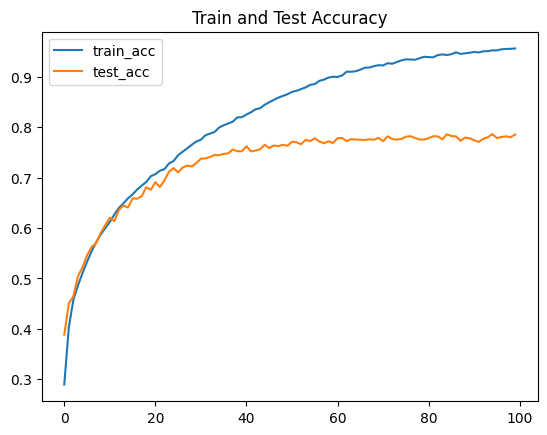

In [94]:
plt.plot(train_accuracies , label = "train_acc")
plt.plot(test_accuracies , label = "test_acc")
plt.legend()
plt.title("Train and Test Accuracy")
plt.show()

# Prediction

In [95]:
import random

In [96]:
def predict_plot_grid(model , dataset , classes , grid_size):
  model.eval()

  fig , axes = plt.subplots(grid_size , grid_size , figsize = (9 , 9))
  for i in range(grid_size):
    for j in range(grid_size):
      idx = random.randint(0 , len(dataset) - 1)
      img , true_label = dataset[idx]
      input_tensor = img.unsqueeze(0).to(device)

      with torch.inference_mode():
        output = model(input_tensor)

        _ , predicted = torch.max(output.data , 1)

      img = img / 2 + 0.5 # Unormalize our images to be able to plot them with matplotlib
      numpy_img = img.cpu().numpy() # numpy expects the image on cpu
      axes[i , j].imshow(np.transpose(numpy_img , (1 , 2 ,0)))

      truth = classes[true_label] == classes[predicted.item()]
      if truth:
        color = "g"
      else:
        color = "r"

      axes[i, j].set_title(f"Truth: {classes[true_label]}\n, Predicted: {classes[predicted.item()]}", fontsize=10, c=color)
      axes[i, j].axis("off")
  plt.tight_layout()
  plt.show()


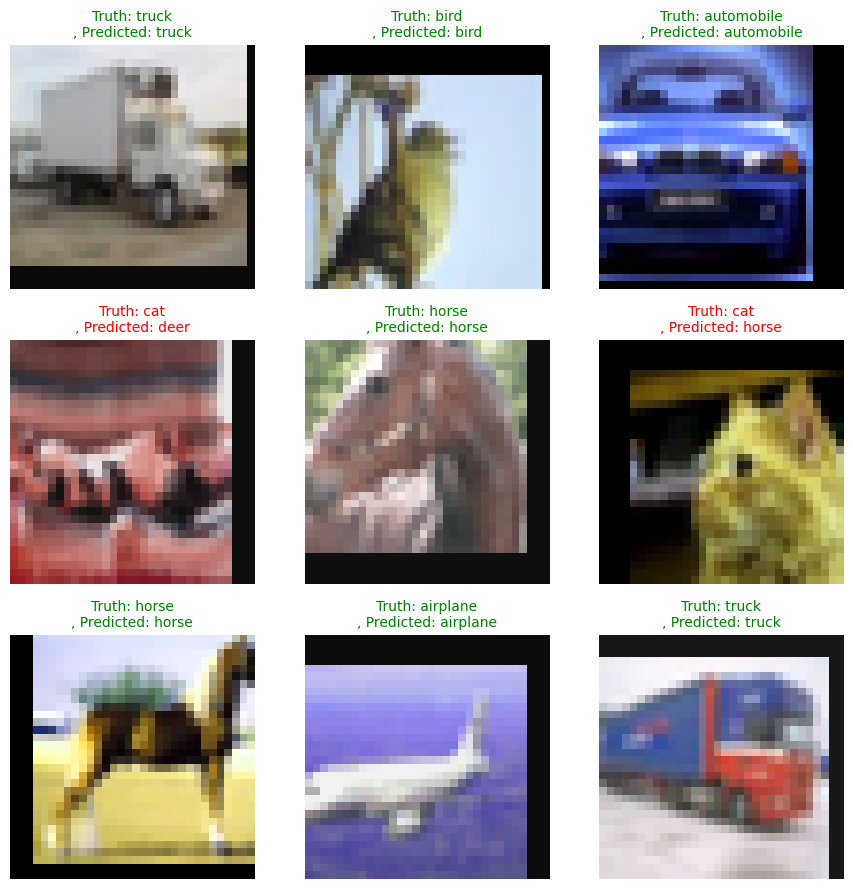

In [97]:
predict_plot_grid(model , test_dataset , train_dataset.classes , 3)

# Save model Before Augmentation

In [98]:
import os

# ===============================
# 1. Save model parameters only (state_dict)
# ===============================
state_dict_dir = "saved_models/state_dict_only"
os.makedirs(state_dict_dir, exist_ok=True)

state_dict_path = os.path.join(state_dict_dir, "model_weights.pth")
torch.save(model.state_dict(), state_dict_path)
print(f"Saved model weights (state_dict) to: {state_dict_path}")

# ===============================
# 2. Save full model (architecture + parameters)
# ===============================
full_model_dir = "saved_models/full_model"
os.makedirs(full_model_dir, exist_ok=True)

full_model_path = os.path.join(full_model_dir, "complete_model.pth")
torch.save(model, full_model_path)
print(f"Saved full model to: {full_model_path}")

Saved model weights (state_dict) to: saved_models/state_dict_only/model_weights.pth
Saved full model to: saved_models/full_model/complete_model.pth


# Save after Augmentation

In [99]:
import os

# ===============================
# 1. Save model parameters only (state_dict)
# ===============================
state_dict_dir = "best_models/state_dict_only"
os.makedirs(state_dict_dir, exist_ok=True)

state_dict_path = os.path.join(state_dict_dir, "model_weights.pth")
torch.save(model.state_dict(), state_dict_path)
print(f"Saved model weights (state_dict) to: {state_dict_path}")

# ===============================
# 2. Save full model (architecture + parameters)
# ===============================
full_model_dir = "best_models/full_model"
os.makedirs(full_model_dir, exist_ok=True)

full_model_path = os.path.join(full_model_dir, "complete_model.pth")
torch.save(model, full_model_path)
print(f"Saved full model to: {full_model_path}")

Saved model weights (state_dict) to: best_models/state_dict_only/model_weights.pth
Saved full model to: best_models/full_model/complete_model.pth


In [100]:
train_accuracies[-1]

0.9563

In [101]:
test_accuracies[-1]

0.7855